# 1.0  Setting the Environment 

In [1]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

2025-04-20 23:32:38.616168: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-20 23:32:38.717343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745217158.757206  651411 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745217158.768838  651411 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745217158.875881  651411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 1.1 Setting the seed 

In [2]:
seed = 803
tf.random.set_seed(seed)
np.random.seed(seed)

## 1.2 Loading the dataset

In [3]:
# Import Fashion MNIST dataset
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Process the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train_one_hot = tf.one_hot(y_train, 10)
y_test_one_hot = tf.one_hot(y_test, 10)

# Hyperparameters from the original assignment
batch_size = 64
hidden_size = 100
learning_rate = 0.01
output_size = 10

I0000 00:00:1745217162.798449  651411 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38483 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:ca:00.0, compute capability: 8.0
I0000 00:00:1745217162.799593  651411 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38483 MB memory:  -> device: 1, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:e3:00.0, compute capability: 8.0


# 2.0 Built in

## 2.1 CNN for Built-in Tensorflow batch Normalization

In [4]:
class CNNWithBatchNorm(tf.keras.Model):
    """
    CNN with Batch Normalization
    """
    def __init__(self):
        super(CNNWithBatchNorm, self).__init__()
        # Conv layer
        self.conv1 = tf.keras.layers.Conv2D(
            filters=30, 
            kernel_size=(5, 5), 
            padding='same',
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Batch normalization after conv
        self.bn1 = tf.keras.layers.BatchNormalization()
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        # Dense layer
        self.fc1 = tf.keras.layers.Dense(
            units=hidden_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Batch normalization after dense
        self.bn2 = tf.keras.layers.BatchNormalization()
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        # Output layer
        self.fc2 = tf.keras.layers.Dense(
            units=output_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
    
    def call(self, inputs, training=True):
        # First conv block with batch norm
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Flatten
        x = self.flatten(x)
        
        # Dense block with batch norm
        x = self.fc1(x)
        x = self.bn2(x, training=training)
        x = self.relu2(x)
        
        # Output layer
        x = self.fc2(x)
        
        return x


## 2.2 CNN for Built-in Tensorflow Layer Normalization

In [5]:
class CNNWithLayerNorm(tf.keras.Model):
    """
    CNN with Layer Normalization
    """
    def __init__(self):
        super(CNNWithLayerNorm, self).__init__()
        # Conv layer
        self.conv1 = tf.keras.layers.Conv2D(
            filters=30, 
            kernel_size=(5, 5), 
            padding='same',
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Layer normalization after conv
        self.ln1 = tf.keras.layers.LayerNormalization()
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        # Dense layer
        self.fc1 = tf.keras.layers.Dense(
            units=hidden_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Layer normalization after dense
        self.ln2 = tf.keras.layers.LayerNormalization()
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        # Output layer
        self.fc2 = tf.keras.layers.Dense(
            units=output_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
    
    def call(self, inputs, training=True):
        # First conv block with layer norm
        x = self.conv1(inputs)
        x = self.ln1(x)  # Layer norm doesn't have training parameter
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Flatten
        x = self.flatten(x)
        
        # Dense block with layer norm
        x = self.fc1(x)
        x = self.ln2(x)  # Layer norm doesn't have training parameter
        x = self.relu2(x)
        
        # Output layer
        x = self.fc2(x)
        
        return x


## 2.3 CNN for Weight Normalization using tensorflow-Addons

In [6]:
class CNNWithWeightNorm(tf.keras.Model):
    """
    CNN with Weight Normalization
    
    Note: TensorFlow doesn't have a built-in weight normalization layer,
    so we're using tfa.layers.WeightNormalization from TensorFlow Addons.
    """
    def __init__(self):
        super(CNNWithWeightNorm, self).__init__()
        try:
            import tensorflow_addons as tfa
            
            # Conv layer with weight normalization
            self.conv1 = tfa.layers.WeightNormalization(
                tf.keras.layers.Conv2D(
                    filters=30, 
                    kernel_size=(5, 5), 
                    padding='same',
                    use_bias=True,
                    kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                    bias_initializer='zeros'
                )
            )
            # ReLU activation
            self.relu1 = tf.keras.layers.ReLU()
            # Max pooling
            self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
            # Flatten
            self.flatten = tf.keras.layers.Flatten()
            # Dense layer with weight normalization
            self.fc1 = tfa.layers.WeightNormalization(
                tf.keras.layers.Dense(
                    units=hidden_size,
                    use_bias=True,
                    kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                    bias_initializer='zeros'
                )
            )
            # ReLU activation
            self.relu2 = tf.keras.layers.ReLU()
            # Output layer with weight normalization
            self.fc2 = tfa.layers.WeightNormalization(
                tf.keras.layers.Dense(
                    units=output_size,
                    use_bias=True,
                    kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                    bias_initializer='zeros'
                )
            )
            self.has_weight_norm = True
            
        except ImportError:
            print("TensorFlow Addons not available. Using standard layers without weight normalization.")
            # Fallback to standard layers
            # Conv layer
            self.conv1 = tf.keras.layers.Conv2D(
                filters=30, 
                kernel_size=(5, 5), 
                padding='same',
                use_bias=True,
                kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                bias_initializer='zeros'
            )
            # ReLU activation
            self.relu1 = tf.keras.layers.ReLU()
            # Max pooling
            self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
            # Flatten
            self.flatten = tf.keras.layers.Flatten()
            # Dense layer
            self.fc1 = tf.keras.layers.Dense(
                units=hidden_size,
                use_bias=True,
                kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                bias_initializer='zeros'
            )
            # ReLU activation
            self.relu2 = tf.keras.layers.ReLU()
            # Output layer
            self.fc2 = tf.keras.layers.Dense(
                units=output_size,
                use_bias=True,
                kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                bias_initializer='zeros'
            )
            self.has_weight_norm = False
    
    def call(self, inputs, training=True):
        # Forward pass
        x = self.conv1(inputs)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu2(x)
        x = self.fc2(x)
        
        return x


## 2.4 CNN for No Normalization

In [7]:
class CNNBaseline(tf.keras.Model):
    """
    CNN without any normalization (baseline)
    """
    def __init__(self):
        super(CNNBaseline, self).__init__()
        # Conv layer
        self.conv1 = tf.keras.layers.Conv2D(
            filters=30, 
            kernel_size=(5, 5), 
            padding='same',
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        # Dense layer
        self.fc1 = tf.keras.layers.Dense(
            units=hidden_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        # Output layer
        self.fc2 = tf.keras.layers.Dense(
            units=output_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
    
    def call(self, inputs, training=True):
        # Forward pass without normalization
        x = self.conv1(inputs)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu2(x)
        x = self.fc2(x)
        
        return x


## 2.5 Training and Evaluation

In [8]:
def train_and_evaluate_model(model, model_name, num_epochs=4):
    """
    Train and evaluate a model
    
    Args:
        model: The model to train
        model_name: Name of the model for logging
        num_epochs: Number of training epochs
        
    Returns:
        Training history and test accuracy
    """
    print(f"\nTraining {model_name}:")
    print("=" * 50)
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    
    # Set up callbacks for timing
    class TimingCallback(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.start_time = time.time()
        
        def on_train_end(self, logs=None):
            self.train_time = time.time() - self.start_time
            print(f"Training completed in {self.train_time:.2f} seconds")
    
    timing_callback = TimingCallback()
    
    # Train model
    history = model.fit(
        x_train, y_train_one_hot,
        batch_size=batch_size,
        epochs=num_epochs,
        verbose=1,
        callbacks=[timing_callback]
    )
    
    # Evaluate model
    test_loss, test_acc = model.evaluate(x_test, y_test_one_hot, verbose=0)
    print(f"Test accuracy: {test_acc*100:.2f}%")
    
    # Return history and test accuracy
    return {
        'loss': history.history['loss'],
        'accuracy': [acc * 100 for acc in history.history['accuracy']],
        'test_acc': test_acc * 100,
        'training_time': timing_callback.train_time
    }



## 2.6 Comparing the results

In [9]:
def compare_normalization_methods(num_epochs=4):
    """
    Compare different normalization methods
    
    Args:
        num_epochs: Number of epochs to train
        
    Returns:
        Dictionary of results
    """
    results = {}
    
    # Create and train models
    print("\nComparing normalization methods...")
    
    # Baseline (no normalization)
    baseline_model = CNNBaseline()
    results['No Normalization'] = train_and_evaluate_model(
        baseline_model, 
        "Baseline (No Normalization)", 
        num_epochs
    )
    
    # Batch Normalization
    batch_norm_model = CNNWithBatchNorm()
    results['Batch Normalization'] = train_and_evaluate_model(
        batch_norm_model, 
        "CNN with Batch Normalization", 
        num_epochs
    )
    
    # Layer Normalization
    layer_norm_model = CNNWithLayerNorm()
    results['Layer Normalization'] = train_and_evaluate_model(
        layer_norm_model, 
        "CNN with Layer Normalization", 
        num_epochs
    )
    
    # Weight Normalization (if TensorFlow Addons is available)
    weight_norm_model = CNNWithWeightNorm()
    if hasattr(weight_norm_model, 'has_weight_norm') and weight_norm_model.has_weight_norm:
        results['Weight Normalization'] = train_and_evaluate_model(
            weight_norm_model, 
            "CNN with Weight Normalization", 
            num_epochs
        )
    
    # Plot results
    plt.figure(figsize=(20, 8))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    for method, result in results.items():
        plt.plot(range(1, num_epochs + 1), result['loss'], label=method)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    for method, result in results.items():
        plt.plot(range(1, num_epochs + 1), result['accuracy'], label=method)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('normalization_comparison.png')
    plt.show()
    
    # Compare test accuracies
    print("\nTest Accuracies:")
    for method, result in results.items():
        print(f"{method}: {result['test_acc']:.2f}%")
    
    # Compare training times
    print("\nTraining Times:")
    for method, result in results.items():
        print(f"{method}: {result['training_time']:.2f} seconds")
    
    # Compare with baseline
    baseline_acc = results['No Normalization']['test_acc']
    print("\nPerformance Improvements over Baseline:")
    for method, result in results.items():
        if method != 'No Normalization':
            improvement = result['test_acc'] - baseline_acc
            print(f"{method}: {improvement:.2f}% improvement")
    
    # Find best method
    best_method = max(results.items(), key=lambda x: x[1]['test_acc'])
    print(f"\nBest performing method: {best_method[0]} with {best_method[1]['test_acc']:.2f}% test accuracy")
    
    return results



## 2.7 Runing the code

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Comparing normalization methods...

Training Baseline (No Normalization):
Epoch 1/4


I0000 00:00:1745217164.381840  651494 service.cc:152] XLA service 0x148e8c006010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745217164.381859  651494 service.cc:160]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
I0000 00:00:1745217164.381861  651494 service.cc:160]   StreamExecutor device (1): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-04-20 23:32:44.400637: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745217164.456876  651494 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-20 23:32:45.701065: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_340', 244 bytes spill stores, 244 bytes spill loads

2025-04-20 23:32:45.701090: I external/local_xla/xla/stream_execu

158/938 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.4057 - loss: 1.7308

I0000 00:00:1745217167.383532  651494 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


920/938 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.6355 - loss: 1.0612

2025-04-20 23:32:48.901302: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_340', 8 bytes spill stores, 8 bytes spill loads



938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6375 - loss: 1.0550
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.8148 - loss: 0.5236
Epoch 3/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step - accuracy: 0.8383 - loss: 0.4600
Epoch 4/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - accuracy: 0.8502 - loss: 0.4272
Training completed in 9.58 seconds
Test accuracy: 83.12%

Training CNN with Batch Normalization:
Epoch 1/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6260 - loss: 1.1936
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8123 - loss: 0.5575
Epoch 3/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8374 - loss: 0.4717
Epoch 4/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8508 - loss: 0.4277
Training completed in 8.21 seconds
Test accuracy: 85.66%

Training CNN with Layer Normalization:
Epoch 1/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6120 - loss: 1.2065
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms

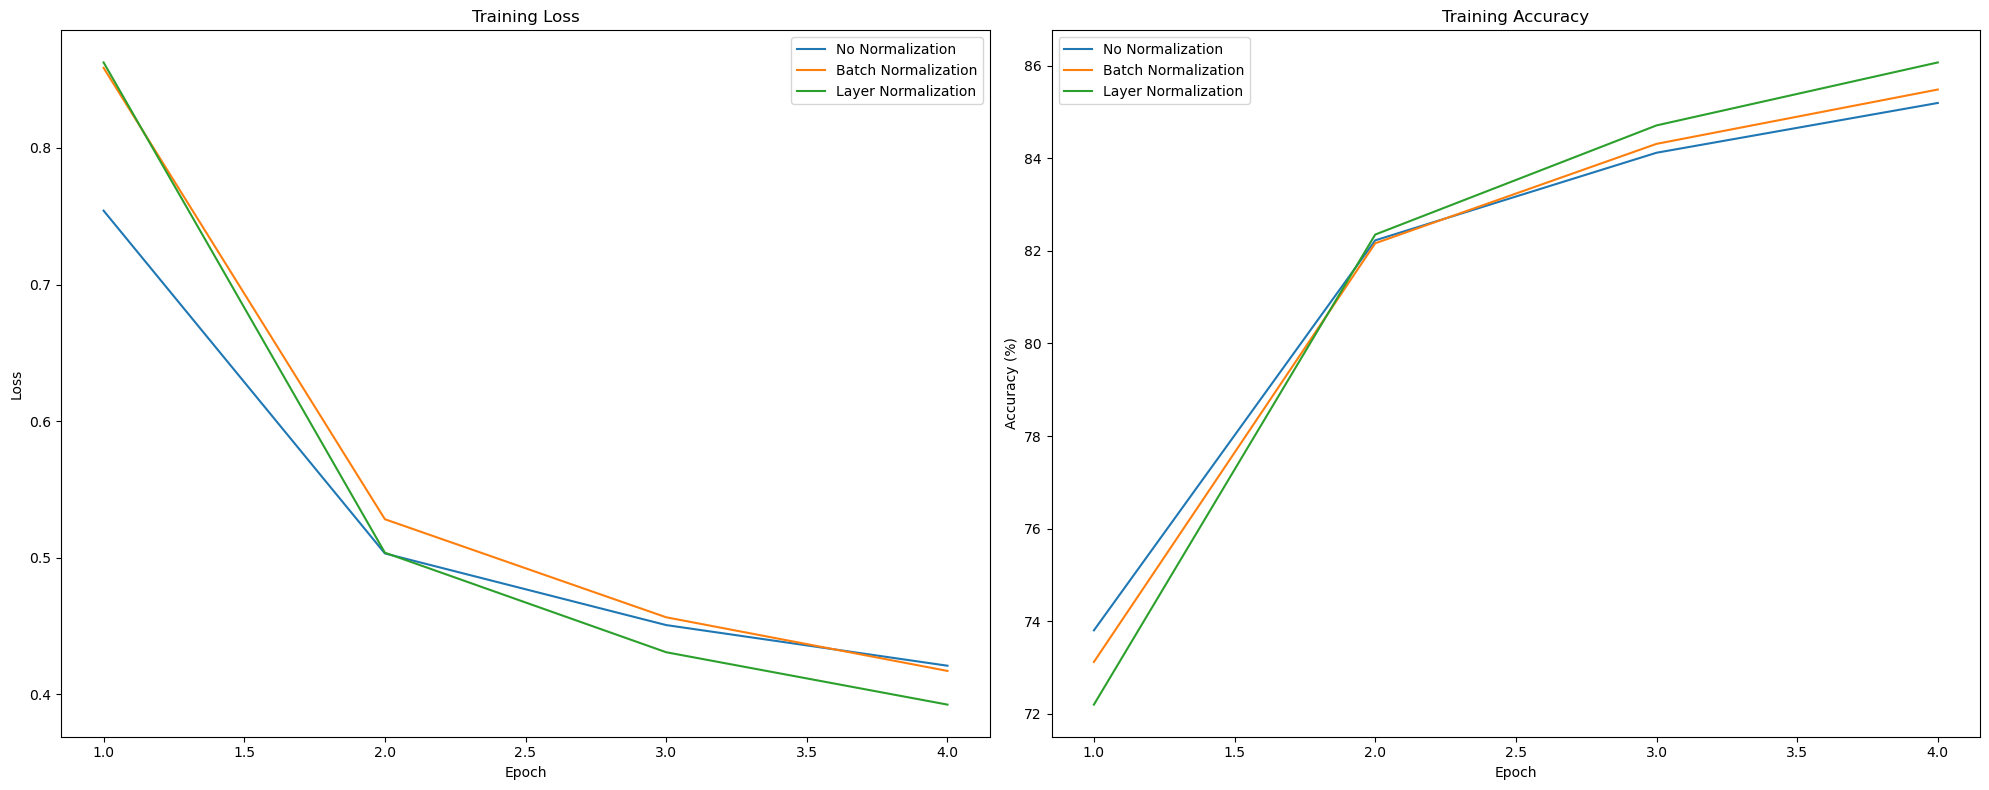


Test Accuracies:
No Normalization: 83.12%
Batch Normalization: 85.66%
Layer Normalization: 85.31%

Training Times:
No Normalization: 9.58 seconds
Batch Normalization: 8.21 seconds
Layer Normalization: 7.15 seconds

Performance Improvements over Baseline:
Batch Normalization: 2.54% improvement
Layer Normalization: 2.19% improvement

Best performing method: Batch Normalization with 85.66% test accuracy

Analysis of why Layer Normalization might be better than Batch Normalization:
1. Layer Normalization normalizes across the feature dimensions, making it independent of batch size
2. Layer Normalization has the same behavior during training and inference
3. Layer Normalization can be more stable for smaller models or datasets
4. Layer Normalization doesn't require maintaining running statistics


In [10]:
def run_builtin():
    print(f"TensorFlow version: {tf.__version__}")
    print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
    
    # Set number of epochs
    num_epochs = 4
    
    # Compare normalization methods
    results = compare_normalization_methods(num_epochs=num_epochs)
    
    print("\nAnalysis of why Layer Normalization might be better than Batch Normalization:")
    print("1. Layer Normalization normalizes across the feature dimensions, making it independent of batch size")
    print("2. Layer Normalization has the same behavior during training and inference")
    print("3. Layer Normalization can be more stable for smaller models or datasets")
    print("4. Layer Normalization doesn't require maintaining running statistics")



run_builtin()

# 3.0 Custom Normalization Techniques

## 3.1 CNN with Custom Batch Normalization

In [11]:
class CNNWithCustomBatchNorm(tf.keras.Model):
    """
    CNN with Custom Batch Normalization
    """
    def __init__(self):
        super(CNNWithCustomBatchNorm, self).__init__()
        # Convolutional layer
        self.conv1 = tf.keras.layers.Conv2D(
            filters=30, 
            kernel_size=(5, 5), 
            padding='same',
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Batch norm parameters for conv layer
        self.gamma1 = tf.Variable(tf.ones([30]), name='gamma1')
        self.beta1 = tf.Variable(tf.zeros([30]), name='beta1')
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        # Dense layer
        self.fc1 = tf.keras.layers.Dense(
            units=hidden_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Batch norm parameters for dense layer
        self.gamma2 = tf.Variable(tf.ones([hidden_size]), name='gamma2')
        self.beta2 = tf.Variable(tf.zeros([hidden_size]), name='beta2')
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        # Output layer
        self.fc2 = tf.keras.layers.Dense(
            units=output_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        
        # Running statistics for inference
        self.running_mean1 = tf.Variable(tf.zeros([30]), trainable=False)
        self.running_var1 = tf.Variable(tf.ones([30]), trainable=False)
        self.running_mean2 = tf.Variable(tf.zeros([hidden_size]), trainable=False)
        self.running_var2 = tf.Variable(tf.ones([hidden_size]), trainable=False)
        self.momentum = 0.99  # Momentum for running statistics
    
    def batch_normalization(self, x, gamma, beta, running_mean, running_var, training=True, epsilon=1e-5):
        """
        Custom implementation of Batch Normalization based on the original paper
        
        Args:
            x: Input tensor
            gamma: Scale parameter
            beta: Shift parameter
            running_mean: Running mean for inference
            running_var: Running variance for inference
            training: Whether in training mode
            epsilon: Small constant for numerical stability
            
        Returns:
            Normalized tensor
        """
        if training:
            # For 4D inputs (NHWC format for conv layers)
            if len(x.shape) == 4:
                # Calculate mean and variance over N, H, W dimensions
                axes = [0, 1, 2]
                # Reshape gamma and beta for broadcasting
                gamma_broadcasted = tf.reshape(gamma, [1, 1, 1, -1])
                beta_broadcasted = tf.reshape(beta, [1, 1, 1, -1])
            else:
                # For 2D inputs (dense layers)
                axes = [0]
                gamma_broadcasted = gamma
                beta_broadcasted = beta
            
            # Compute batch statistics
            batch_mean, batch_var = tf.nn.moments(x, axes=axes)
            
            # Update running statistics
            running_mean.assign(self.momentum * running_mean + (1 - self.momentum) * batch_mean)
            running_var.assign(self.momentum * running_var + (1 - self.momentum) * batch_var)
            
            # Normalize, scale and shift
            x_norm = (x - tf.reshape(batch_mean, [-1] + [1] * (len(x.shape) - len(batch_mean.shape) - 1) + [batch_mean.shape[0]])) / \
                     tf.sqrt(tf.reshape(batch_var, [-1] + [1] * (len(x.shape) - len(batch_var.shape) - 1) + [batch_var.shape[0]]) + epsilon)
            return gamma_broadcasted * x_norm + beta_broadcasted
        else:
            # Use running statistics for inference
            if len(x.shape) == 4:
                # Reshape for broadcasting
                gamma_broadcasted = tf.reshape(gamma, [1, 1, 1, -1])
                beta_broadcasted = tf.reshape(beta, [1, 1, 1, -1])
                running_mean_broadcasted = tf.reshape(running_mean, [1, 1, 1, -1])
                running_var_broadcasted = tf.reshape(running_var, [1, 1, 1, -1])
            else:
                gamma_broadcasted = gamma
                beta_broadcasted = beta
                running_mean_broadcasted = running_mean
                running_var_broadcasted = running_var
            
            # Normalize using running statistics
            x_norm = (x - running_mean_broadcasted) / tf.sqrt(running_var_broadcasted + epsilon)
            return gamma_broadcasted * x_norm + beta_broadcasted
    
    def call(self, inputs, training=True):
        # First conv layer
        x = self.conv1(inputs)
        # Apply custom batch normalization
        x = self.batch_normalization(x, self.gamma1, self.beta1, 
                                    self.running_mean1, self.running_var1, 
                                    training=training)
        # ReLU activation
        x = self.relu1(x)
        # Max pooling
        x = self.pool1(x)
        # Flatten
        x = self.flatten(x)
        # Dense layer
        x = self.fc1(x)
        # Apply custom batch normalization
        x = self.batch_normalization(x, self.gamma2, self.beta2, 
                                    self.running_mean2, self.running_var2, 
                                    training=training)
        # ReLU activation
        x = self.relu2(x)
        # Output layer
        x = self.fc2(x)
        
        return x


## 3.2 CNN for Custom Layer Normalization

In [12]:
class CNNWithCustomLayerNorm(tf.keras.Model):
    """
    CNN with Custom Layer Normalization
    """
    def __init__(self):
        super(CNNWithCustomLayerNorm, self).__init__()
        # Convolutional layer
        self.conv1 = tf.keras.layers.Conv2D(
            filters=30, 
            kernel_size=(5, 5), 
            padding='same',
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Layer norm parameters for conv layer
        self.gamma1 = tf.Variable(tf.ones([30]), name='gamma1')
        self.beta1 = tf.Variable(tf.zeros([30]), name='beta1')
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        # Dense layer
        self.fc1 = tf.keras.layers.Dense(
            units=hidden_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # Layer norm parameters for dense layer
        self.gamma2 = tf.Variable(tf.ones([hidden_size]), name='gamma2')
        self.beta2 = tf.Variable(tf.zeros([hidden_size]), name='beta2')
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        # Output layer
        self.fc2 = tf.keras.layers.Dense(
            units=output_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
    
    def layer_normalization(self, x, gamma, beta, epsilon=1e-5):
        """
        Custom implementation of Layer Normalization
        
        Args:
            x: Input tensor
            gamma: Scale parameter
            beta: Shift parameter
            epsilon: Small constant for numerical stability
            
        Returns:
            Normalized tensor
        """
        # For 4D inputs (NHWC format for conv layers)
        if len(x.shape) == 4:
            # Calculate mean and variance over feature dimensions (H, W, C)
            axes = [1, 2, 3]
            # Reshape gamma and beta for broadcasting
            gamma_broadcasted = tf.reshape(gamma, [1, 1, 1, -1])
            beta_broadcasted = tf.reshape(beta, [1, 1, 1, -1])
        else:
            # For 2D inputs (dense layers) - normalize across feature dimension
            axes = [1]
            gamma_broadcasted = gamma
            beta_broadcasted = beta
        
        # Compute layer statistics per sample
        mean, var = tf.nn.moments(x, axes=axes, keepdims=True)
        
        # Normalize, scale and shift
        x_norm = (x - mean) / tf.sqrt(var + epsilon)
        return gamma_broadcasted * x_norm + beta_broadcasted
    
    def call(self, inputs, training=True):
        # First conv layer
        x = self.conv1(inputs)
        # Apply custom layer normalization
        x = self.layer_normalization(x, self.gamma1, self.beta1)
        # ReLU activation
        x = self.relu1(x)
        # Max pooling
        x = self.pool1(x)
        # Flatten
        x = self.flatten(x)
        # Dense layer
        x = self.fc1(x)
        # Apply custom layer normalization
        x = self.layer_normalization(x, self.gamma2, self.beta2)
        # ReLU activation
        x = self.relu2(x)
        # Output layer
        x = self.fc2(x)
        
        return x


In [13]:
# class CNNWithCustomWeightNorm(tf.keras.Model):
#     """
#     CNN with Custom Weight Normalization - Improved Implementation
#     """
#     def __init__(self):
#         super(CNNWithCustomWeightNorm, self).__init__()
#         # Conv layer parameters
#         self.filter_shape = [5, 5, 1, 30]
#         self.v1 = tf.Variable(
#             tf.random.normal(self.filter_shape, stddev=0.05),  # Reduced stddev for stability
#             name='v1'
#         )
#         self.g1 = tf.Variable(tf.ones([30]), name='g1')
#         self.b1 = tf.Variable(tf.zeros([30]), name='b1')
        
#         # ReLU activation
#         self.relu1 = tf.keras.layers.ReLU()
        
#         # Max pooling
#         self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        
#         # Flatten
#         self.flatten = tf.keras.layers.Flatten()
        
#         # Dense layer parameters
#         self.v2 = tf.Variable(
#             tf.random.normal([14*14*30, hidden_size], stddev=0.05),  # Reduced stddev
#             name='v2'
#         )
#         self.g2 = tf.Variable(tf.ones([hidden_size]), name='g2')
#         self.b2 = tf.Variable(tf.zeros([hidden_size]), name='b2')
        
#         # ReLU activation
#         self.relu2 = tf.keras.layers.ReLU()
        
#         # Output layer parameters
#         self.v3 = tf.Variable(
#             tf.random.normal([hidden_size, output_size], stddev=0.05),  # Reduced stddev
#             name='v3'
#         )
#         self.g3 = tf.Variable(tf.ones([output_size]), name='g3')
#         self.b3 = tf.Variable(tf.zeros([output_size]), name='b3')
        
#         # Flag to track initialization
#         self.initialized = False
    
#     def weight_normalization(self, v, g):
#         """
#         Custom implementation of Weight Normalization
        
#         Args:
#             v: Weight parameter vector
#             g: Scale parameter
            
#         Returns:
#             Normalized weight
#         """
#         if len(v.shape) == 4:  # For conv weights
#             # Reshape for norm calculation
#             v_flat = tf.reshape(v, [-1, v.shape[-1]])
#             # Calculate the L2 norm with epsilon for numerical stability
#             norm = tf.sqrt(tf.reduce_sum(tf.square(v_flat), axis=0) + 1e-12)
#             # Normalize
#             v_norm = v / tf.reshape(norm, [1, 1, 1, -1])
#             # Apply scale
#             return tf.reshape(g, [1, 1, 1, -1]) * v_norm
#         else:  # For dense weights
#             # Calculate the L2 norm with epsilon for numerical stability
#             norm = tf.sqrt(tf.reduce_sum(tf.square(v), axis=0) + 1e-12)
#             # Normalize and scale
#             return g * v / norm
    
#     def initialize_g(self):
#         """
#         Initialize g parameters to the norm of the initial weights
#         as recommended in the original paper
#         """
#         # For conv layer
#         v1_flat = tf.reshape(self.v1, [-1, self.v1.shape[-1]])
#         norm1 = tf.sqrt(tf.reduce_sum(tf.square(v1_flat), axis=0) + 1e-12)
#         self.g1.assign(norm1)
        
#         # For dense layers
#         norm2 = tf.sqrt(tf.reduce_sum(tf.square(self.v2), axis=0) + 1e-12)
#         self.g2.assign(norm2)
        
#         norm3 = tf.sqrt(tf.reduce_sum(tf.square(self.v3), axis=0) + 1e-12)
#         self.g3.assign(norm3)
        
#         print("Weight normalization parameters initialized.")
    
#     def initialize_parameters(self):
#         """
#         Initialize all model parameters
#         """
#         # Call forward pass with dummy data to initialize variables
#         dummy_input = tf.zeros((1, 28, 28, 1))
#         _ = self(dummy_input, training=True)
#         # Initialize g parameters
#         self.initialize_g()
#         self.initialized = True
    
#     def custom_conv2d(self, x, v, g, b):
#         """
#         Custom convolution operation with weight normalization
        
#         Args:
#             x: Input tensor
#             v: Weight parameter
#             g: Scale parameter
#             b: Bias parameter
            
#         Returns:
#             Convolution output
#         """
#         # Apply weight normalization
#         w = self.weight_normalization(v, g)
#         # Perform convolution
#         return tf.nn.conv2d(x, w, strides=[1, 1, 1, 1], padding='SAME') + b
    
#     def custom_dense(self, x, v, g, b):
#         """
#         Custom dense operation with weight normalization
        
#         Args:
#             x: Input tensor
#             v: Weight parameter
#             g: Scale parameter
#             b: Bias parameter
            
#         Returns:
#             Dense output
#         """
#         # Apply weight normalization
#         w = self.weight_normalization(v, g)
#         # Perform matrix multiplication
#         return tf.matmul(x, w) + b
    
#     def call(self, inputs, training=True):
#         # Ensure parameters are initialized
#         if not self.initialized and training:
#             # Only initialize once
#             self.initialize_parameters()
        
#         # Conv layer with weight normalization
#         x = self.custom_conv2d(inputs, self.v1, self.g1, self.b1)
#         # ReLU activation
#         x = self.relu1(x)
#         # Max pooling
#         x = self.pool1(x)
#         # Flatten
#         x = self.flatten(x)
#         # Dense layer with weight normalization
#         x = self.custom_dense(x, self.v2, self.g2, self.b2)
#         # ReLU activation
#         x = self.relu2(x)
#         # Output layer with weight normalization
#         x = self.custom_dense(x, self.v3, self.g3, self.b3)
        
#         return x

## 3.3 CNN for Custom weight

In [14]:
class CNNWithCustomWeightNorm(tf.keras.Model):
    """
    CNN with Custom Weight Normalization
    """
    def __init__(self):
        super(CNNWithCustomWeightNorm, self).__init__()
        # Conv layer parameters
        self.filter_shape = [5, 5, 1, 30]
        self.v1 = tf.Variable(
            tf.random.normal(self.filter_shape, stddev=0.1),
            name='v1'
        )
        self.g1 = tf.Variable(tf.ones([30]), name='g1')
        self.b1 = tf.Variable(tf.zeros([30]), name='b1')
        
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        
        # Dense layer parameters
        self.v2 = tf.Variable(
            tf.random.normal([14*14*30, hidden_size], stddev=0.1),
            name='v2'
        )
        self.g2 = tf.Variable(tf.ones([hidden_size]), name='g2')
        self.b2 = tf.Variable(tf.zeros([hidden_size]), name='b2')
        
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        
        # Output layer parameters
        self.v3 = tf.Variable(
            tf.random.normal([hidden_size, output_size], stddev=0.1),
            name='v3'
        )
        self.g3 = tf.Variable(tf.ones([output_size]), name='g3')
        self.b3 = tf.Variable(tf.zeros([output_size]), name='b3')
    
    def weight_normalization(self, v, g):
        """
        Custom implementation of Weight Normalization
        
        Args:
            v: Weight parameter vector
            g: Scale parameter
            
        Returns:
            Normalized weight
        """
        if len(v.shape) == 4:  # For conv weights
            # Reshape to 2D for normalization
            v_reshaped = tf.reshape(v, [-1, v.shape[-1]])
            # Calculate the norm along each output dimension
            norm = tf.sqrt(tf.reduce_sum(tf.square(v_reshaped), axis=0, keepdims=True))
            # Normalize and scale
            v_normalized = v_reshaped / (norm + 1e-5)
            # Reshape back to 4D
            v_normalized = tf.reshape(v_normalized, v.shape)
            # Apply scaling factor g
            g_reshaped = tf.reshape(g, [1, 1, 1, -1])
            return g_reshaped * v_normalized
        else:  # For dense weights
            # Calculate the norm along the input dimension
            norm = tf.sqrt(tf.reduce_sum(tf.square(v), axis=0, keepdims=True))
            # Normalize and scale
            return g * v / (norm + 1e-5)
    
    def custom_conv2d(self, x, v, g, b):
        """
        Custom convolution operation with weight normalization
        
        Args:
            x: Input tensor
            v: Weight parameter
            g: Scale parameter
            b: Bias parameter
            
        Returns:
            Convolution output
        """
        # Apply weight normalization
        w = self.weight_normalization(v, g)
        # Perform convolution
        return tf.nn.conv2d(x, w, strides=[1, 1, 1, 1], padding='SAME') + b
    
    def custom_dense(self, x, v, g, b):
        """
        Custom dense operation with weight normalization
        
        Args:
            x: Input tensor
            v: Weight parameter
            g: Scale parameter
            b: Bias parameter
            
        Returns:
            Dense output
        """
        # Apply weight normalization
        w = self.weight_normalization(v, g)
        # Perform matrix multiplication
        return tf.matmul(x, w) + b
    
    def call(self, inputs, training=True):
        # Conv layer with weight normalization
        x = self.custom_conv2d(inputs, self.v1, self.g1, self.b1)
        # ReLU activation
        x = self.relu1(x)
        # Max pooling
        x = self.pool1(x)
        # Flatten
        x = self.flatten(x)
        # Dense layer with weight normalization
        x = self.custom_dense(x, self.v2, self.g2, self.b2)
        # ReLU activation
        x = self.relu2(x)
        # Output layer with weight normalization
        x = self.custom_dense(x, self.v3, self.g3, self.b3)
        
        return x

## 3.4 CNN for No normalization

In [15]:
class CNNBaseline(tf.keras.Model):
    """
    CNN without any normalization (baseline)
    """
    def __init__(self):
        super(CNNBaseline, self).__init__()
        # Conv layer
        self.conv1 = tf.keras.layers.Conv2D(
            filters=30, 
            kernel_size=(5, 5), 
            padding='same',
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # ReLU activation
        self.relu1 = tf.keras.layers.ReLU()
        # Max pooling
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)
        # Flatten
        self.flatten = tf.keras.layers.Flatten()
        # Dense layer
        self.fc1 = tf.keras.layers.Dense(
            units=hidden_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
        # ReLU activation
        self.relu2 = tf.keras.layers.ReLU()
        # Output layer
        self.fc2 = tf.keras.layers.Dense(
            units=output_size,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            bias_initializer='zeros'
        )
    
    def call(self, inputs, training=True):
        # Forward pass without normalization
        x = self.conv1(inputs)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu2(x)
        x = self.fc2(x)
        
        return x
        

## 3.5 Train and Evaluate

In [16]:
def train_and_evaluate_model(model, model_name, num_epochs=4):
    """
    Train and evaluate a model
    
    Args:
        model: The model to train
        model_name: Name of the model for logging
        num_epochs: Number of training epochs
        
    Returns:
        Training history and test accuracy
    """
    print(f"\nTraining {model_name}:")
    print("=" * 50)
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    
    # Set up callbacks for timing
    class TimingCallback(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.start_time = time.time()
        
        def on_train_end(self, logs=None):
            self.train_time = time.time() - self.start_time
            print(f"Training completed in {self.train_time:.2f} seconds")
    
    timing_callback = TimingCallback()
    
    # Train model
    history = model.fit(
        x_train, y_train_one_hot,
        batch_size=batch_size,
        epochs=num_epochs,
        verbose=1,
        callbacks=[timing_callback]
    )
    
    # Evaluate model
    test_loss, test_acc = model.evaluate(x_test, y_test_one_hot, verbose=0)
    print(f"Test accuracy: {test_acc*100:.2f}%")
    
    # Return history and test accuracy
    return {
        'loss': history.history['loss'],
        'accuracy': [acc * 100 for acc in history.history['accuracy']],
        'test_acc': test_acc * 100,
        'training_time': timing_callback.train_time
    }



## 3.6 Comparing the Results

In [17]:
def compare_normalization_methods(num_epochs=4):
    """
    Compare different custom normalization methods
    
    Args:
        num_epochs: Number of epochs to train
        
    Returns:
        Dictionary of results
    """
    results = {}
    
    # Create and train models
    print("\nComparing custom normalization methods...")
    
    # Baseline (no normalization)
    baseline_model = CNNBaseline()
    results['No Normalization'] = train_and_evaluate_model(
        baseline_model, 
        "Baseline (No Normalization)", 
        num_epochs
    )
    
    # Custom Batch Normalization
    batch_norm_model = CNNWithCustomBatchNorm()
    results['Custom Batch Normalization'] = train_and_evaluate_model(
        batch_norm_model, 
        "CNN with Custom Batch Normalization", 
        num_epochs
    )
    
    # Custom Layer Normalization
    layer_norm_model = CNNWithCustomLayerNorm()
    results['Custom Layer Normalization'] = train_and_evaluate_model(
        layer_norm_model, 
        "CNN with Custom Layer Normalization", 
        num_epochs
    )
    
    # Custom Weight Normalization
    weight_norm_model = CNNWithCustomWeightNorm()
    results['Custom Weight Normalization'] = train_and_evaluate_model(
        weight_norm_model, 
        "CNN with Custom Weight Normalization", 
        num_epochs
    )
    
    # Plot results
    plt.figure(figsize=(20, 8))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    for method, result in results.items():
        plt.plot(range(1, num_epochs + 1), result['loss'], label=method)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    for method, result in results.items():
        plt.plot(range(1, num_epochs + 1), result['accuracy'], label=method)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('custom_normalization_comparison.png')
    plt.show()
    
    # Compare test accuracies
    print("\nTest Accuracies:")
    for method, result in results.items():
        print(f"{method}: {result['test_acc']:.2f}%")
    
    # Compare training times
    print("\nTraining Times:")
    for method, result in results.items():
        print(f"{method}: {result['training_time']:.2f} seconds")
    
    # Compare with baseline
    baseline_acc = results['No Normalization']['test_acc']
    print("\nPerformance Improvements over Baseline:")
    for method, result in results.items():
        if method != 'No Normalization':
            improvement = result['test_acc'] - baseline_acc
            print(f"{method}: {improvement:.2f}% improvement")
    
    # Find best method
    best_method = max(results.items(), key=lambda x: x[1]['test_acc'])
    print(f"\nBest performing method: {best_method[0]} with {best_method[1]['test_acc']:.2f}% test accuracy")
    
    return results



## 3.7 Running the code

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Comparing custom normalization methods...

Training Baseline (No Normalization):
Epoch 1/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6445 - loss: 1.0414
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - accuracy: 0.8078 - loss: 0.5316
Epoch 3/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step - accuracy: 0.8323 - loss: 0.4721
Epoch 4/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.8468 - loss: 0.4371
Training completed in 5.78 seconds
Test accuracy: 81.75%

Training CNN with Custom Batch Normalization:
Epoch 1/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6276 - loss: 1.1976
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8171 - loss: 0.5605
Epoch 3/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8409 - loss: 0.4731
Epoch 4/4
938/938 ━━━━━━━━━━━━━━━━━━━━

/home/da2623/.local/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0578 - loss: 2.3330
Epoch 2/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.0578 - loss: 2.3330
Epoch 3/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.0578 - loss: 2.3330
Epoch 4/4
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.0578 - loss: 2.3330
Training completed in 4.64 seconds
Test accuracy: 5.77%


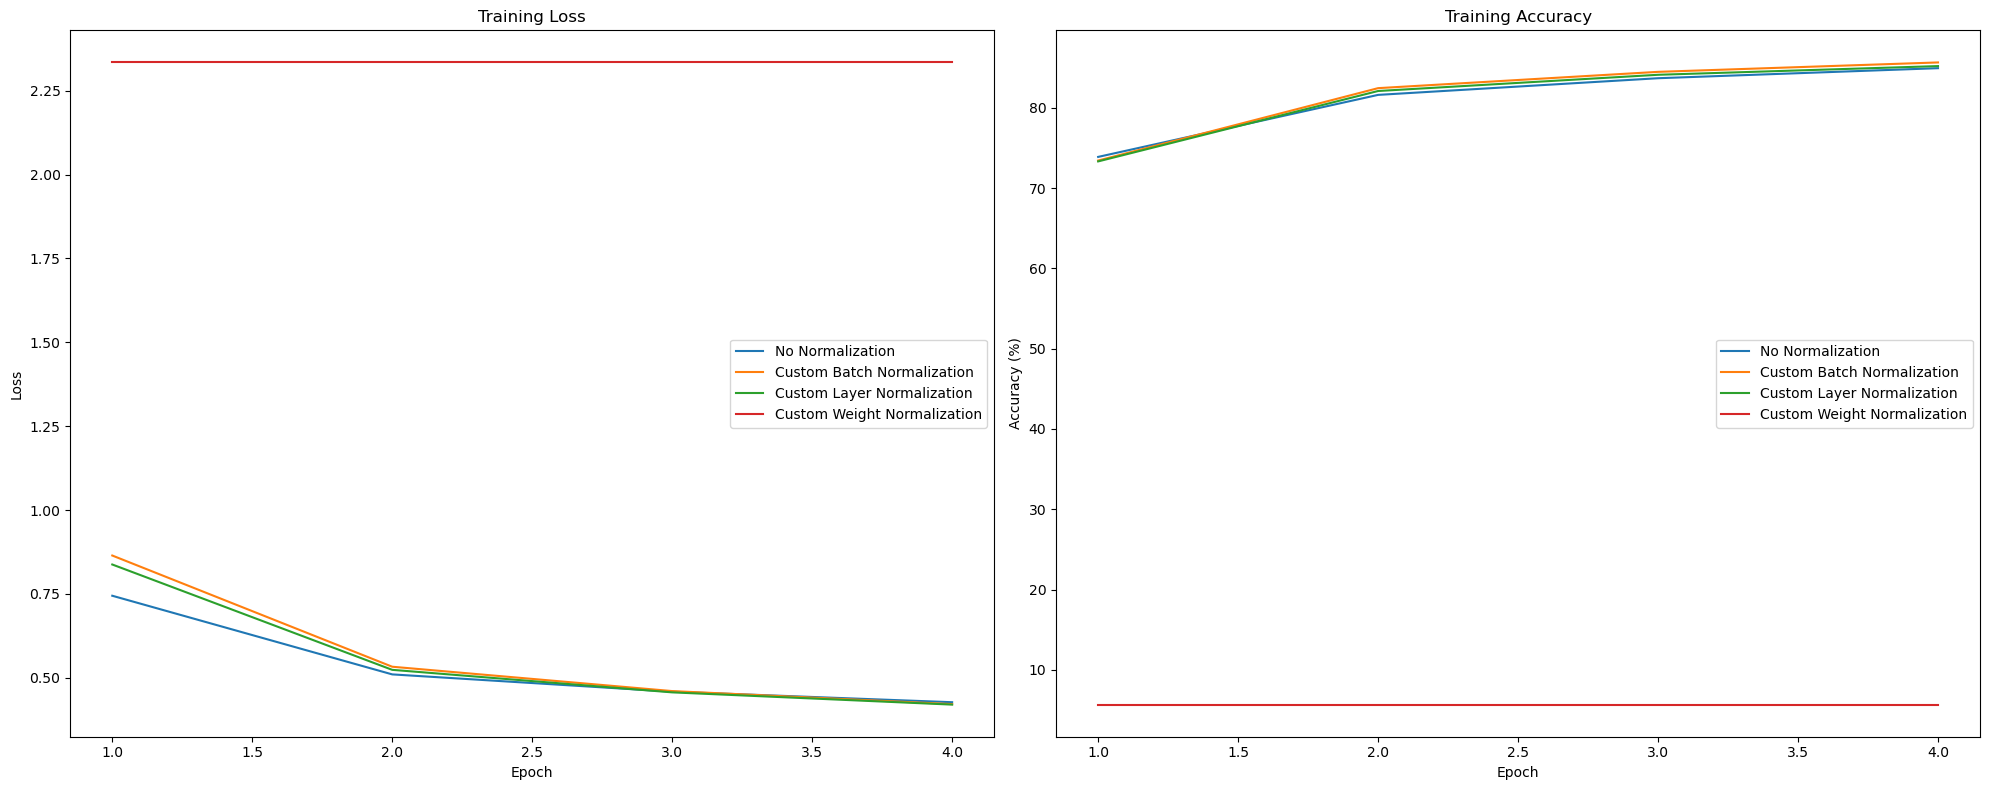


Test Accuracies:
No Normalization: 81.75%
Custom Batch Normalization: 84.80%
Custom Layer Normalization: 84.76%
Custom Weight Normalization: 5.77%

Training Times:
No Normalization: 5.78 seconds
Custom Batch Normalization: 8.41 seconds
Custom Layer Normalization: 6.93 seconds
Custom Weight Normalization: 4.64 seconds

Performance Improvements over Baseline:
Custom Batch Normalization: 3.05% improvement
Custom Layer Normalization: 3.01% improvement
Custom Weight Normalization: -75.98% improvement

Best performing method: Custom Batch Normalization with 84.80% test accuracy

Explanation of Normalization Methods:

1. Batch Normalization:
   - Normalizes activations across the mini-batch dimension
   - Formula: x_hat = (x - μ_B) / sqrt(σ²_B + ε), where μ_B and σ²_B are batch statistics
   - Output: y = γ * x_hat + β, where γ and β are learnable parameters

2. Layer Normalization:
   - Normalizes across the feature dimensions for each sample independently
   - Formula: x_hat = (x - μ_L) / 

In [18]:
def run_custom():
    print(f"TensorFlow version: {tf.__version__}")
    print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
    
    # Set number of epochs
    num_epochs = 4
    
    # Compare custom normalization methods
    results = compare_normalization_methods(num_epochs=num_epochs)
    
    print("\nExplanation of Normalization Methods:")
    print("\n1. Batch Normalization:")
    print("   - Normalizes activations across the mini-batch dimension")
    print("   - Formula: x_hat = (x - μ_B) / sqrt(σ²_B + ε), where μ_B and σ²_B are batch statistics")
    print("   - Output: y = γ * x_hat + β, where γ and β are learnable parameters")
    
    print("\n2. Layer Normalization:")
    print("   - Normalizes across the feature dimensions for each sample independently")
    print("   - Formula: x_hat = (x - μ_L) / sqrt(σ²_L + ε), where μ_L and σ²_L are calculated per sample")
    print("   - Output: y = γ * x_hat + β, where γ and β are learnable parameters")
    
    print("\n3. Weight Normalization:")
    print("   - Reparameterizes the weights by decoupling the direction from the magnitude")
    print("   - Formula: w = (g / ||v||) * v, where g is a scalar and v is a vector")
    print("   - Optimizes g and v separately during training")
    
    print("\nWhy Layer Normalization might be better than Batch Normalization:")
    print("1. Independent of batch size - works well with small batches")
    print("2. Same behavior during training and inference (no need to track running statistics)")
    print("3. Normalizes each sample independently, more stable in various contexts")
    print("4. Less affected by distribution shifts in the input data")

run_custom()